In [26]:
import os
import sys
import argparse
import xarray as xr
import numpy as np
import pandas as pd

In [53]:
# source = "scream"
source = "era5"

out_dir = f"/pscratch/sd/w/wcmca1/hackathon/etc_data/stats/"
# Create output directory if it doesn't exist
os.makedirs(out_dir, exist_ok=True)

# # ETC COF parquet file
# etc_path = "/pscratch/sd/w/wcmca1/hackathon/etc_tracks/"
# etc_file = f"{etc_path}/{source}_etc_cof_data.parquet"
# print(f"{etc_file} exists: {os.path.isfile(etc_file)}")

# ETC 2D Zarr file
zarr_path = f"/pscratch/sd/w/wcmca1/hackathon/etc_data/{source}/"
zarr_file = f"{zarr_path}/etc_2d_combined_all_all.zarr"
print(f"{zarr_file} exists: {os.path.isdir(zarr_file)}")

/pscratch/sd/w/wcmca1/hackathon/etc_data/era5//etc_2d_combined_all_all.zarr exists: True


In [28]:
# etc_df = pd.read_parquet(etc_file)
# etc_df.head()

In [29]:
ds = xr.open_zarr(zarr_file, consolidated=True)
ds

<xarray.Dataset> Size: 84GB
Dimensions:                  (time: 28945, y: 161, x: 161)
Coordinates:
  * time                     (time) datetime64[ns] 232kB 2019-08-01 ... 2021-...
  * x                        (x) int64 1kB -80 -79 -78 -77 -76 ... 77 78 79 80
  * y                        (y) int64 1kB -80 -79 -78 -77 -76 ... 77 78 79 80
Data variables: (12/38)
    ar_etc_overlap_mask      (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    ar_mcs_etc_overlap_mask  (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    ar_tracks_str            (time) <U11 1MB dask.array<chunksize=(7237,), meta=np.ndarray>
    cof_lat                  (time) float64 232kB dask.array<chunksize=(28945,), meta=np.ndarray>
    cof_lon                  (time) float64 232kB dask.array<chunksize=(28945,), meta=np.ndarray>
    d2m                      (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    ...                       ...
    ua_850hPa                (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    v10                      (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    va_500hPa                (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    va_850hPa                (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    zg_500hPa                (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    zg_850hPa                (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
Attributes:
    combination_date:    2025-11-25T00:48:00
    combined_variables:  ar_etc_overlap_mask, ar_mcs_etc_overlap_mask, d2m, e...
    creation_time:       2025-11-22T13:18:49.797897
    description:         ETC storm extracted 2D data with relative coordinates
    grid_center_x:       0
    grid_center_y:       0
    lat_res:             0.25
    lon_res:             0.25
    num_variables:       28
    radius:              20.0

In [30]:
ds.x, ds.y

(<xarray.DataArray 'x' (x: 161)> Size: 1kB
 array([-80, -79, -78, -77, -76, -75, -74, -73, -72, -71, -70, -69, -68, -67,
        -66, -65, -64, -63, -62, -61, -60, -59, -58, -57, -56, -55, -54, -53,
        -52, -51, -50, -49, -48, -47, -46, -45, -44, -43, -42, -41, -40, -39,
        -38, -37, -36, -35, -34, -33, -32, -31, -30, -29, -28, -27, -26, -25,
        -24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13, -12, -11,
        -10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,   3,
          4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,  15,  16,  17,
         18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,  31,
         32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,  45,
         46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,  57,  58,  59,
         60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  73,
         74,  75,  76,  77,  78,  79,  80])
 Coordinates:
   * x        (x) int64 1kB -80 -79 -78 -

In [ ]:
ds.overlap_flag.plot.hist()

In [ ]:
nh_lat_threshold = 20.0
sh_lat_threshold = -20.0
mask_nh = (ds.cof_lat > nh_lat_threshold).compute()
mask_sh = (ds.cof_lat < sh_lat_threshold).compute()

# Overlap flag values: 0: isolated ETC; 1: MCS only; 2: AR only; 3: MCS+AR
# overlap_flag_val = 2
overlap_categories = [
    ('isolated', 0, 'Isolated (no overlaps)'),
    ('mcs_only', 1, 'MCS only'),
    ('ar_only', 2, 'AR only'),
    ('3way', 3, 'MCS+AR (3-way)')
]

overlap_categories[2], overlap_categories[2][1]

mask_nh_overlap = ((ds.overlap_flag == overlap_categories[2][1]) & mask_nh).compute()
nh_count = mask_nh_overlap.sum().values
nh_count

In [ ]:
diff_lat = ds.storm_lat - ds.cof_lat
diff_lon = ds.storm_lon - ds.cof_lon
diff_lat.max().values, diff_lon.max().values

In [ ]:
ds_ol = ds.where(mask_nh_overlap, drop=True)
ds_ol

In [ ]:
ds_ol.ar_etc_overlap_mask.isel(time=120).plot()

In [ ]:
def convert_masks_and_create_exclusive_precip(ds, overlap_category='3way'):
    """
    Convert overlap masks to binary frequency variables and create exclusive precipitation variables.
    
    Parameters:
    -----------
    ds : xarray.Dataset
        Dataset containing overlap mask variables
    overlap_category : str
        Type of overlap analysis:
        - '3way': ETC+AR+MCS (3-way overlap, overlap_flag=3)
        - 'mcs_only': ETC+MCS only (overlap_flag=1)
        - 'ar_only': ETC+AR only (overlap_flag=2)
        - 'isolated': ETC only, no overlaps (overlap_flag=0)
    
    Returns:
    --------
    ds_binary : xarray.Dataset
        Dataset with binary frequency variables and exclusive precipitation
    """
    print(f"\n  Converting masks for overlap category: {overlap_category}")
    
    ds_binary = ds.copy()
    
    if overlap_category == '3way':
        # 3-way overlap: ETC+AR+MCS
        mask_vars = ['ar_mcs_etc_overlap_mask', 'mcs_ar_etc_overlap_mask', 'etc_mcs_ar_overlap_mask']
        available_mask_vars = [v for v in mask_vars if v in ds.data_vars]
        
        if not available_mask_vars:
            print("  WARNING: No mask variables found for ETC+AR+MCS")
            return ds_binary
        
        print(f"  Converting mask variables to binary (0/1): {available_mask_vars}")
        
        # Convert masks to binary (0/1)
        ar_mask_binary = xr.where(ds['ar_mcs_etc_overlap_mask'] > 0, 1, 0) if 'ar_mcs_etc_overlap_mask' in ds else None
        mcs_mask_binary = xr.where(ds['mcs_ar_etc_overlap_mask'] > 0, 1, 0) if 'mcs_ar_etc_overlap_mask' in ds else None
        etc_mask_binary = xr.where(ds['etc_mcs_ar_overlap_mask'] > 0, 1, 0) if 'etc_mcs_ar_overlap_mask' in ds else None
        
        # Create frequency variables
        if ar_mask_binary is not None:
            ds_binary['ar_freq'] = ar_mask_binary
            ds_binary['ar_freq'].attrs = {
                'long_name': 'AR frequency',
                'description': 'Frequency of AR occurrence (0-1)',
                'units': '1'
            }
        
        if mcs_mask_binary is not None:
            ds_binary['mcs_freq'] = mcs_mask_binary
            ds_binary['mcs_freq'].attrs = {
                'long_name': 'MCS frequency',
                'description': 'Frequency of MCS occurrence (0-1)',
                'units': '1'
            }
        
        if etc_mask_binary is not None:
            ds_binary['etc_freq'] = etc_mask_binary
            ds_binary['etc_freq'].attrs = {
                'long_name': 'ETC frequency',
                'description': 'Frequency of ETC occurrence (0-1)',
                'units': '1'
            }
        
        # Remove old mask variable names
        for old_name in available_mask_vars:
            if old_name in ds_binary:
                ds_binary = ds_binary.drop_vars(old_name)
        
        # Create exclusive precipitation variables
        if 'pr' in ds and ar_mask_binary is not None and mcs_mask_binary is not None and etc_mask_binary is not None:
            print(f"  Creating exclusive precipitation variables (pr_ar, pr_mcs, pr_etc)")
            
            # AR exclusive: AR present, but not MCS
            ar_exclusive = (ar_mask_binary == 1) & (mcs_mask_binary == 0)
            
            # MCS exclusive: MCS present, but not AR
            mcs_exclusive = (mcs_mask_binary == 1) & (ar_mask_binary == 0)
            
            # ETC exclusive: ETC present, but not in MCS nor AR
            etc_exclusive = (etc_mask_binary == 1) & (mcs_mask_binary == 0) & (ar_mask_binary == 0)
            
            ds_binary['pr_ar'] = xr.where(ar_exclusive, ds['pr'], 0)
            ds_binary['pr_ar'].attrs = {
                'long_name': 'Precipitation under AR only',
                'description': 'Precipitation occurring under AR mask exclusively (not under MCS)',
                'units': ds['pr'].attrs.get('units', 'kg m-2 s-1')
            }
            
            ds_binary['pr_mcs'] = xr.where(mcs_exclusive, ds['pr'], 0)
            ds_binary['pr_mcs'].attrs = {
                'long_name': 'Precipitation under MCS only',
                'description': 'Precipitation occurring under MCS mask exclusively (not under AR)',
                'units': ds['pr'].attrs.get('units', 'kg m-2 s-1')
            }
            
            ds_binary['pr_etc'] = xr.where(etc_exclusive, ds['pr'], 0)
            ds_binary['pr_etc'].attrs = {
                'long_name': 'Precipitation under ETC only',
                'description': 'Precipitation occurring under ETC mask exclusively (not under MCS nor AR)',
                'units': ds['pr'].attrs.get('units', 'kg m-2 s-1')
            }
    
    elif overlap_category == 'mcs_only':
        # 2-way overlap: ETC+MCS only
        mask_vars = ['mcs_etc_overlap_mask', 'etc_mcs_overlap_mask']
        available_mask_vars = [v for v in mask_vars if v in ds.data_vars]
        
        if not available_mask_vars:
            print("  WARNING: No mask variables found for ETC+MCS")
            return ds_binary
        
        print(f"  Converting mask variables to binary (0/1): {available_mask_vars}")
        
        # Convert masks to binary (0/1)
        mcs_mask_binary = xr.where(ds['mcs_etc_overlap_mask'] > 0, 1, 0) if 'mcs_etc_overlap_mask' in ds else None
        etc_mask_binary = xr.where(ds['etc_mcs_overlap_mask'] > 0, 1, 0) if 'etc_mcs_overlap_mask' in ds else None
        
        # Create frequency variables
        if mcs_mask_binary is not None:
            ds_binary['mcs_freq'] = mcs_mask_binary
            ds_binary['mcs_freq'].attrs = {
                'long_name': 'MCS frequency',
                'description': 'Frequency of MCS occurrence (0-1)',
                'units': '1'
            }
        
        if etc_mask_binary is not None:
            ds_binary['etc_freq'] = etc_mask_binary
            ds_binary['etc_freq'].attrs = {
                'long_name': 'ETC frequency',
                'description': 'Frequency of ETC occurrence (0-1)',
                'units': '1'
            }
        
        # Remove old mask variable names
        for old_name in available_mask_vars:
            if old_name in ds_binary:
                ds_binary = ds_binary.drop_vars(old_name)
        
        # Create precipitation variables separated by MCS mask
        if 'pr' in ds and mcs_mask_binary is not None:
            print(f"  Creating precipitation variables (pr_mcs, pr_nonmcs)")
            
            # MCS: precipitation where MCS is present
            mcs_mask = (mcs_mask_binary == 1)
            
            # Non-MCS: precipitation where MCS is not present
            nonmcs_mask = (mcs_mask_binary == 0)
            
            ds_binary['pr_mcs'] = xr.where(mcs_mask, ds['pr'], 0)
            ds_binary['pr_mcs'].attrs = {
                'long_name': 'Precipitation under MCS',
                'description': 'Precipitation occurring where MCS mask is present',
                'units': ds['pr'].attrs.get('units', 'kg m-2 s-1')
            }
            
            ds_binary['pr_nonmcs'] = xr.where(nonmcs_mask, ds['pr'], 0)
            ds_binary['pr_nonmcs'].attrs = {
                'long_name': 'Precipitation under non-MCS',
                'description': 'Precipitation occurring where MCS mask is not present',
                'units': ds['pr'].attrs.get('units', 'kg m-2 s-1')
            }
    
    elif overlap_category == 'ar_only':
        # 2-way overlap: ETC+AR only
        mask_vars = ['etc_ar_overlap_mask', 'ar_etc_overlap_mask']
        available_mask_vars = [v for v in mask_vars if v in ds.data_vars]
        
        if not available_mask_vars:
            print("  WARNING: No mask variables found for ETC+AR")
            return ds_binary
        
        print(f"  Converting mask variables to binary (0/1): {available_mask_vars}")
        
        # Convert masks to binary (0/1)
        etc_mask_binary = xr.where(ds['etc_ar_overlap_mask'] > 0, 1, 0) if 'etc_ar_overlap_mask' in ds else None
        ar_mask_binary = xr.where(ds['ar_etc_overlap_mask'] > 0, 1, 0) if 'ar_etc_overlap_mask' in ds else None
        
        # Create frequency variables
        if etc_mask_binary is not None:
            ds_binary['etc_freq'] = etc_mask_binary
            ds_binary['etc_freq'].attrs = {
                'long_name': 'ETC frequency',
                'description': 'Frequency of ETC occurrence (0-1)',
                'units': '1'
            }
        
        if ar_mask_binary is not None:
            ds_binary['ar_freq'] = ar_mask_binary
            ds_binary['ar_freq'].attrs = {
                'long_name': 'AR frequency',
                'description': 'Frequency of AR occurrence (0-1)',
                'units': '1'
            }
        
        # Remove old mask variable names
        for old_name in available_mask_vars:
            if old_name in ds_binary:
                ds_binary = ds_binary.drop_vars(old_name)
        
        # Create precipitation variables separated by AR mask
        if 'pr' in ds and ar_mask_binary is not None:
            print(f"  Creating precipitation variables (pr_ar, pr_nonar)")
            
            # AR: precipitation where AR is present
            ar_mask = (ar_mask_binary == 1)
            
            # Non-AR: precipitation where AR is not present
            nonar_mask = (ar_mask_binary == 0)
            
            ds_binary['pr_ar'] = xr.where(ar_mask, ds['pr'], 0)
            ds_binary['pr_ar'].attrs = {
                'long_name': 'Precipitation under AR',
                'description': 'Precipitation occurring where AR mask is present',
                'units': ds['pr'].attrs.get('units', 'kg m-2 s-1')
            }
            
            ds_binary['pr_nonar'] = xr.where(nonar_mask, ds['pr'], 0)
            ds_binary['pr_nonar'].attrs = {
                'long_name': 'Precipitation under non-AR',
                'description': 'Precipitation occurring where AR mask is not present',
                'units': ds['pr'].attrs.get('units', 'kg m-2 s-1')
            }
    
    elif overlap_category == 'isolated':
        # Isolated ETC: no overlaps with AR or MCS
        # For isolated cases, we only need ETC frequency
        # No exclusive precipitation variables since there are no overlaps
        print(f"  Note: 'isolated' category has ETC only, no AR/MCS overlaps")
        
        # Just copy the dataset, no mask conversion needed for isolated
        # The overlap_flag filtering will handle selecting isolated cases
        
    else:
        print(f"  WARNING: Unknown overlap_category '{overlap_category}' - using original dataset")
        return ds
    
    return ds_binary

In [ ]:
overlap_categories[2]

In [ ]:
ds_binary = convert_masks_and_create_exclusive_precip(ds, overlap_category='ar_only')
ds_binary

In [ ]:
# ds_bindary.ar_freq
ds_overlap = ds_binary.where(mask_nh_overlap, drop=True)
ds_overlap

In [ ]:
ds_overlap.ar_freq.isel(time=50).plot()

In [ ]:
ds_overlap.ar_freq.mean(dim='time', skipna=True, keep_attrs=True).plot()

## Spatial Statistics Functions

Functions to compute statistics over spatial dimensions (x, y) to condense the 3D data into 1D time series.

In [45]:
def create_circular_mask(x_dim, y_dim, radius_deg):
    """
    Create a boolean circular mask centered at (0, 0).
    
    Parameters:
    -----------
    x_dim : xarray.DataArray
        X coordinate array (centered at 0)
    y_dim : xarray.DataArray
        Y coordinate array (centered at 0)
    radius_deg : float
        Radius in degrees
    
    Returns:
    --------
    mask : xarray.DataArray
        Boolean mask (True inside circle, False outside)
    """
    # Create distance field from center
    distance = np.sqrt(x_dim**2 + y_dim**2)
    mask = distance <= radius_deg
    return mask


def compute_spatial_stats_basic(ds, variables, radius_deg=10):
    """
    Compute mean, min, max for regular variables within circular radius.
    
    Parameters:
    -----------
    ds : xarray.Dataset
        Input dataset with dimensions (time, y, x)
    variables : list of str
        Variable names to compute statistics for
    radius_deg : float
        Radius in degrees (default: 10)
    
    Returns:
    --------
    stats_ds : xarray.Dataset
        Dataset with computed statistics (time dimension only)
    """
    # Create circular mask
    mask = create_circular_mask(ds.x, ds.y, radius_deg)
    
    # Initialize result dictionary
    stats_dict = {}
    
    for var_name in variables:
        if var_name not in ds:
            print(f"  WARNING: Variable '{var_name}' not found, skipping")
            continue
        
        # Apply mask and compute statistics
        var_masked = ds[var_name].where(mask)
        
        # Compute statistics along spatial dimensions (vectorized)
        stats_dict[f'{var_name}_mean'] = var_masked.mean(dim=['x', 'y'], skipna=True)
        stats_dict[f'{var_name}_min'] = var_masked.min(dim=['x', 'y'], skipna=True)
        stats_dict[f'{var_name}_max'] = var_masked.max(dim=['x', 'y'], skipna=True)
        
        # Add attributes
        orig_units = ds[var_name].attrs.get('units', '1')
        stats_dict[f'{var_name}_mean'].attrs = {
            'long_name': f'Mean {var_name} within {radius_deg}° radius',
            'units': orig_units
        }
        stats_dict[f'{var_name}_min'].attrs = {
            'long_name': f'Min {var_name} within {radius_deg}° radius',
            'units': orig_units
        }
        stats_dict[f'{var_name}_max'].attrs = {
            'long_name': f'Max {var_name} within {radius_deg}° radius',
            'units': orig_units
        }
    
    # Create output dataset
    stats_ds = xr.Dataset(stats_dict)
    
    return stats_ds


def compute_mask_fractional_area(ds, mask_variables, radii=[10, 15]):
    """
    Compute fractional area coverage for feature masks within circular radii.
    
    Parameters:
    -----------
    ds : xarray.Dataset
        Input dataset with dimensions (time, y, x)
    mask_variables : list of str
        Variable names ending with '_overlap_mask'
    radii : list of float
        List of radii in degrees (default: [10, 15])
    
    Returns:
    --------
    stats_ds : xarray.Dataset
        Dataset with fractional area coverage (time dimension only)
    """
    stats_dict = {}
    
    for radius_deg in radii:
        # Create circular mask
        circle_mask = create_circular_mask(ds.x, ds.y, radius_deg)
        total_pixels = circle_mask.sum().values  # Total pixels in circle
        
        for var_name in mask_variables:
            if var_name not in ds:
                print(f"  WARNING: Variable '{var_name}' not found, skipping")
                continue
            
            # Count pixels where mask > 0 within the circle
            # Vectorized: (mask > 0) & circle_mask, then sum over x,y
            feature_present = (ds[var_name] > 0) & circle_mask
            feature_count = feature_present.sum(dim=['x', 'y'])
            
            # Compute fractional area
            fractional_area = feature_count / total_pixels
            
            # Store result
            output_name = f'{var_name}_frac_r{int(radius_deg)}'
            stats_dict[output_name] = fractional_area
            stats_dict[output_name].attrs = {
                'long_name': f'Fractional area coverage of {var_name} within {radius_deg}° radius',
                'units': '1',
                'description': f'Fraction of pixels with mask > 0 within {radius_deg}° radius'
            }
    
    # Create output dataset
    stats_ds = xr.Dataset(stats_dict)
    
    return stats_ds


def compute_feature_precipitation_stats(ds, radius_deg=10):
    """
    Compute domain-mean precipitation separated by features uniformly.
    
    This computes feature-specific precipitation statistics regardless of overlap_flag.
    Variables that don't exist will naturally result in NaN or 0, which is informative.
    
    Note: Total pr_mean should be computed via compute_spatial_stats_basic() to avoid duplication.
    
    Parameters:
    -----------
    ds : xarray.Dataset
        Input dataset with 'pr' and mask variables
    radius_deg : float
        Radius in degrees (default: 10)
    
    Returns:
    --------
    stats_ds : xarray.Dataset
        Dataset with feature-specific precipitation statistics
    """
    # Create circular mask
    circle_mask = create_circular_mask(ds.x, ds.y, radius_deg)
    total_pixels = circle_mask.sum().values  # Total pixels in circle
    
    stats_dict = {}
    
    if 'pr' not in ds:
        print("  WARNING: 'pr' variable not found")
        return xr.Dataset()
    
    # Get precipitation variable
    pr = ds['pr'].where(circle_mask)  # Only consider pixels within radius
    
    # AR-related precipitation (if AR mask exists)
    if 'ar_etc_overlap_mask' in ds:
        ar_mask = (ds['ar_etc_overlap_mask'] > 0) & circle_mask
        
        # Precipitation where AR is present
        pr_ar = (pr * ar_mask).sum(dim=['x', 'y']) / total_pixels
        stats_dict['pr_ar_mean'] = pr_ar
        stats_dict['pr_ar_mean'].attrs = {
            'long_name': 'Domain-mean precipitation from AR',
            'units': pr.attrs.get('units', 'mm h-1'),
            'description': f'Sum of pr under AR mask / total pixels in {radius_deg}° radius'
        }
        
        # Precipitation where AR is not present
        pr_nonar = (pr * (~ar_mask & circle_mask)).sum(dim=['x', 'y']) / total_pixels
        stats_dict['pr_nonar_mean'] = pr_nonar
        stats_dict['pr_nonar_mean'].attrs = {
            'long_name': 'Domain-mean precipitation from non-AR',
            'units': pr.attrs.get('units', 'mm h-1'),
            'description': f'Sum of pr outside AR mask / total pixels in {radius_deg}° radius'
        }
    
    # Alternative AR mask (for 3-way overlaps)
    if 'ar_mcs_etc_overlap_mask' in ds:
        ar_mask_3way = (ds['ar_mcs_etc_overlap_mask'] > 0) & circle_mask
        
        # AR exclusive (not under MCS) - for 3-way comparisons
        if 'mcs_ar_etc_overlap_mask' in ds:
            mcs_mask_3way = (ds['mcs_ar_etc_overlap_mask'] > 0) & circle_mask
            ar_exclusive = ar_mask_3way & ~mcs_mask_3way
            
            pr_ar_excl = (pr * ar_exclusive).sum(dim=['x', 'y']) / total_pixels
            stats_dict['pr_ar_excl_mean'] = pr_ar_excl
            stats_dict['pr_ar_excl_mean'].attrs = {
                'long_name': 'Domain-mean precipitation from AR (exclusive of MCS)',
                'units': pr.attrs.get('units', 'mm h-1'),
                'description': f'Sum of pr under AR mask (not MCS) / total pixels in {radius_deg}° radius'
            }
    
    # MCS-related precipitation (if MCS mask exists)
    if 'mcs_etc_overlap_mask' in ds:
        mcs_mask = (ds['mcs_etc_overlap_mask'] > 0) & circle_mask
        
        # Precipitation where MCS is present
        pr_mcs = (pr * mcs_mask).sum(dim=['x', 'y']) / total_pixels
        stats_dict['pr_mcs_mean'] = pr_mcs
        stats_dict['pr_mcs_mean'].attrs = {
            'long_name': 'Domain-mean precipitation from MCS',
            'units': pr.attrs.get('units', 'mm h-1'),
            'description': f'Sum of pr under MCS mask / total pixels in {radius_deg}° radius'
        }
        
        # Precipitation where MCS is not present
        pr_nonmcs = (pr * (~mcs_mask & circle_mask)).sum(dim=['x', 'y']) / total_pixels
        stats_dict['pr_nonmcs_mean'] = pr_nonmcs
        stats_dict['pr_nonmcs_mean'].attrs = {
            'long_name': 'Domain-mean precipitation from non-MCS',
            'units': pr.attrs.get('units', 'mm h-1'),
            'description': f'Sum of pr outside MCS mask / total pixels in {radius_deg}° radius'
        }
    
    # Alternative MCS mask (for 3-way overlaps)
    if 'mcs_ar_etc_overlap_mask' in ds:
        mcs_mask_3way = (ds['mcs_ar_etc_overlap_mask'] > 0) & circle_mask
        
        # MCS exclusive (not under AR) - for 3-way comparisons
        if 'ar_mcs_etc_overlap_mask' in ds:
            ar_mask_3way = (ds['ar_mcs_etc_overlap_mask'] > 0) & circle_mask
            mcs_exclusive = mcs_mask_3way & ~ar_mask_3way
            
            pr_mcs_excl = (pr * mcs_exclusive).sum(dim=['x', 'y']) / total_pixels
            stats_dict['pr_mcs_excl_mean'] = pr_mcs_excl
            stats_dict['pr_mcs_excl_mean'].attrs = {
                'long_name': 'Domain-mean precipitation from MCS (exclusive of AR)',
                'units': pr.attrs.get('units', 'mm h-1'),
                'description': f'Sum of pr under MCS mask (not AR) / total pixels in {radius_deg}° radius'
            }
    
    # ETC-related precipitation (for 3-way overlaps)
    if 'etc_mcs_ar_overlap_mask' in ds:
        etc_mask = (ds['etc_mcs_ar_overlap_mask'] > 0) & circle_mask
        
        # ETC exclusive (not under MCS nor AR) - for 3-way comparisons
        if 'ar_mcs_etc_overlap_mask' in ds and 'mcs_ar_etc_overlap_mask' in ds:
            ar_mask_3way = (ds['ar_mcs_etc_overlap_mask'] > 0) & circle_mask
            mcs_mask_3way = (ds['mcs_ar_etc_overlap_mask'] > 0) & circle_mask
            etc_exclusive = etc_mask & ~mcs_mask_3way & ~ar_mask_3way
            
            pr_etc = (pr * etc_exclusive).sum(dim=['x', 'y']) / total_pixels
            stats_dict['pr_etc_mean'] = pr_etc
            stats_dict['pr_etc_mean'].attrs = {
                'long_name': 'Domain-mean precipitation from ETC (exclusive of MCS and AR)',
                'units': pr.attrs.get('units', 'mm h-1'),
                'description': f'Sum of pr under ETC mask (not MCS/AR) / total pixels in {radius_deg}° radius'
            }
    
    # Create output dataset
    stats_ds = xr.Dataset(stats_dict)
    
    return stats_ds


def compute_all_spatial_stats(ds, 
                               basic_vars=None, 
                               mask_vars=None,
                               basic_radius=10,
                               mask_radii=[10, 15],
                               pr_radius=10):
    """
    Main function to compute all spatial statistics uniformly for all time points.
    
    This function computes statistics for all time points regardless of overlap_flag.
    The overlap_flag is preserved as a coordinate variable for filtering during analysis.
    
    Parameters:
    -----------
    ds : xarray.Dataset
        Input dataset with dimensions (time, y, x)
    basic_vars : list of str, optional
        Variables for basic statistics (mean/min/max)
    mask_vars : list of str, optional
        Mask variables for fractional area
    basic_radius : float
        Radius for basic statistics (default: 10)
    mask_radii : list of float
        Radii for mask statistics (default: [10, 15])
    pr_radius : float
        Radius for precipitation statistics (default: 10)
    
    Returns:
    --------
    combined_ds : xarray.Dataset
        Combined dataset with all statistics and overlap_flag as coordinate
    """
    print(f"\nComputing spatial statistics for all time points")
    print(f"  Input shape: {dict(ds.sizes)}")
    
    stats_datasets = []
    
    # 1. Basic statistics for regular variables
    if basic_vars:
        print(f"  Computing basic stats (mean/min/max) for {len(basic_vars)} variables...")
        stats_basic = compute_spatial_stats_basic(ds, basic_vars, radius_deg=basic_radius)
        stats_datasets.append(stats_basic)
    
    # 2. Fractional area for mask variables
    if mask_vars:
        print(f"  Computing fractional area for {len(mask_vars)} mask variables...")
        stats_masks = compute_mask_fractional_area(ds, mask_vars, radii=mask_radii)
        stats_datasets.append(stats_masks)
    
    # 3. Feature precipitation statistics (computed uniformly for all time points)
    print(f"  Computing feature-specific precipitation statistics...")
    stats_pr = compute_feature_precipitation_stats(ds, radius_deg=pr_radius)
    stats_datasets.append(stats_pr)
    
    # Combine all statistics
    combined_ds = xr.merge(stats_datasets)
    
    # Add overlap_flag as a coordinate variable for easy filtering
    if 'overlap_flag' in ds:
        combined_ds = combined_ds.assign_coords({'overlap_flag': ds.overlap_flag})
        print(f"  Added overlap_flag as coordinate for filtering")
    
    # Add other useful coordinates
    if 'cof_lat' in ds:
        combined_ds = combined_ds.assign_coords({'cof_lat': ds.cof_lat})
    if 'cof_lon' in ds:
        combined_ds = combined_ds.assign_coords({'cof_lon': ds.cof_lon})
    if 'storm_id' in ds:
        combined_ds = combined_ds.assign_coords({'storm_id': ds.storm_id})
    
    # Add metadata
    combined_ds.attrs['basic_radius_deg'] = basic_radius
    combined_ds.attrs['mask_radii_deg'] = mask_radii
    combined_ds.attrs['pr_radius_deg'] = pr_radius
    combined_ds.attrs['description'] = 'Spatial statistics computed within circular radii centered at ETC. overlap_flag coordinate: 0=isolated, 1=mcs_only, 2=ar_only, 3=3way'
    
    print(f"  Output variables: {len(combined_ds.data_vars)}")
    print(f"  Output shape: {dict(combined_ds.sizes)}")
    print(f"  Coordinates: {list(combined_ds.coords)}")
    
    return combined_ds

## Test the Functions

Let's test with the AR-only overlap category.

In [46]:
# Define variables for analysis
# Get all available non-mask variables (exclude metadata and masks)
metadata_vars = ['storm_id', 'grid_id', 'lon_id', 'lat_id', 'storm_lat', 'storm_lon', 
                 'overlap_flag', 'ar_tracks_str', 'mcs_tracks_str', 'cof_lat', 'cof_lon']
mask_vars = [v for v in ds.data_vars if v.endswith('_overlap_mask')]
basic_vars = [v for v in ds.data_vars if v not in metadata_vars and v not in mask_vars]

print(f"Basic variables ({len(basic_vars)}): {basic_vars}")
print(f"\nMask variables ({len(mask_vars)}): {mask_vars}")

Basic variables (21): ['d2m', 'hur_500hPa', 'hur_850hPa', 'hus_500hPa', 'hus_850hPa', 'omega_500hPa', 'omega_850hPa', 'pr', 'prw', 'ps', 'psl', 'sstk', 'tas', 'u10', 'ua_500hPa', 'ua_850hPa', 'v10', 'va_500hPa', 'va_850hPa', 'zg_500hPa', 'zg_850hPa']

Mask variables (7): ['ar_etc_overlap_mask', 'ar_mcs_etc_overlap_mask', 'etc_ar_overlap_mask', 'etc_mcs_ar_overlap_mask', 'etc_mcs_overlap_mask', 'mcs_ar_etc_overlap_mask', 'mcs_etc_overlap_mask']


In [47]:
# # Filter dataset by hemisphere only (process all overlap flags)
# # Note: We no longer pre-filter by overlap_flag - it's preserved as a coordinate

# ds_filtered = ds.where(mask_nh, drop=True)
# print(f"Filtered dataset (NH only) shape: {dict(ds_filtered.sizes)}")
# print(f"Overlap flag distribution:")
# print(ds_filtered.overlap_flag.to_series().value_counts().sort_index())

In [48]:
ds

<xarray.Dataset> Size: 84GB
Dimensions:                  (time: 28945, y: 161, x: 161)
Coordinates:
  * time                     (time) datetime64[ns] 232kB 2019-08-01 ... 2021-...
  * x                        (x) int64 1kB -80 -79 -78 -77 -76 ... 77 78 79 80
  * y                        (y) int64 1kB -80 -79 -78 -77 -76 ... 77 78 79 80
Data variables: (12/38)
    ar_etc_overlap_mask      (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    ar_mcs_etc_overlap_mask  (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    ar_tracks_str            (time) <U11 1MB dask.array<chunksize=(7237,), meta=np.ndarray>
    cof_lat                  (time) float64 232kB dask.array<chunksize=(28945,), meta=np.ndarray>
    cof_lon                  (time) float64 232kB dask.array<chunksize=(28945,), meta=np.ndarray>
    d2m                      (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    ...                       ...
    ua_850hPa                (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    v10                      (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    va_500hPa                (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    va_850hPa                (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    zg_500hPa                (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    zg_850hPa                (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
Attributes:
    combination_date:    2025-11-25T00:48:00
    combined_variables:  ar_etc_overlap_mask, ar_mcs_etc_overlap_mask, d2m, e...
    creation_time:       2025-11-22T13:18:49.797897
    description:         ETC storm extracted 2D data with relative coordinates
    grid_center_x:       0
    grid_center_y:       0
    lat_res:             0.25
    lon_res:             0.25
    num_variables:       28
    radius:              20.0

In [49]:
# Compute all spatial statistics (for all overlap flags at once)
stats = compute_all_spatial_stats(
    ds,
    basic_vars=basic_vars,
    mask_vars=mask_vars,
    basic_radius=10,
    mask_radii=[10, 15],
    pr_radius=10
)

stats


Computing spatial statistics for all time points
  Input shape: {'time': 28945, 'y': 161, 'x': 161}
  Computing basic stats (mean/min/max) for 21 variables...
  Computing fractional area for 7 mask variables...
  Computing feature-specific precipitation statistics...
  Added overlap_flag as coordinate for filtering
  Output variables: 84
  Output shape: {'time': 28945}
  Coordinates: ['time', 'overlap_flag', 'cof_lat', 'cof_lon', 'storm_id']
  Added overlap_flag as coordinate for filtering
  Output variables: 84
  Output shape: {'time': 28945}
  Coordinates: ['time', 'overlap_flag', 'cof_lat', 'cof_lon', 'storm_id']


<xarray.Dataset> Size: 13MB
Dimensions:                           (time: 28945)
Coordinates:
  * time                              (time) datetime64[ns] 232kB 2019-08-01 ...
    overlap_flag                      (time) float64 232kB dask.array<chunksize=(28945,), meta=np.ndarray>
    cof_lat                           (time) float64 232kB dask.array<chunksize=(28945,), meta=np.ndarray>
    cof_lon                           (time) float64 232kB dask.array<chunksize=(28945,), meta=np.ndarray>
    storm_id                          (time) int64 232kB dask.array<chunksize=(28945,), meta=np.ndarray>
Data variables: (12/84)
    d2m_mean                          (time) float32 116kB dask.array<chunksize=(1000,), meta=np.ndarray>
    d2m_min                           (time) float32 116kB dask.array<chunksize=(1000,), meta=np.ndarray>
    d2m_max                           (time) float32 116kB dask.array<chunksize=(1000,), meta=np.ndarray>
    hur_500hPa_mean                   (time) float32 116kB dask.array<chunksize=(1000,), meta=np.ndarray>
    hur_500hPa_min                    (time) float32 116kB dask.array<chunksize=(1000,), meta=np.ndarray>
    hur_500hPa_max                    (time) float32 116kB dask.array<chunksize=(1000,), meta=np.ndarray>
    ...                                ...
    pr_nonar_mean                     (time) float64 232kB dask.array<chunksize=(1000,), meta=np.ndarray>
    pr_ar_excl_mean                   (time) float64 232kB dask.array<chunksize=(1000,), meta=np.ndarray>
    pr_mcs_mean                       (time) float64 232kB dask.array<chunksize=(1000,), meta=np.ndarray>
    pr_nonmcs_mean                    (time) float64 232kB dask.array<chunksize=(1000,), meta=np.ndarray>
    pr_mcs_excl_mean                  (time) float64 232kB dask.array<chunksize=(1000,), meta=np.ndarray>
    pr_etc_mean                       (time) float64 232kB dask.array<chunksize=(1000,), meta=np.ndarray>
Attributes:
    basic_radius_deg:  10
    mask_radii_deg:    [10, 15]
    pr_radius_deg:     10
    description:       Spatial statistics computed within circular radii cent...

In [51]:
# Check some of the computed statistics
print("Sample statistics (first 5 time points):")
print(f"\nOverlap flags: {stats.overlap_flag.values[:5]}")
print(f"Precipitation (pr) mean: {stats.pr_mean.values[:5]}")

# AR-related (will be 0/NaN when no AR mask present)
if 'pr_ar_mean' in stats:
    print(f"PR from AR mean: {stats.pr_ar_mean.values[:5]}")
    print(f"PR from non-AR mean: {stats.pr_nonar_mean.values[:5]}")

# MCS-related (will be 0/NaN when no MCS mask present)
if 'pr_mcs_mean' in stats:
    print(f"PR from MCS mean: {stats.pr_mcs_mean.values[:5]}")
    print(f"PR from non-MCS mean: {stats.pr_nonmcs_mean.values[:5]}")

print(f"\nAR fractional area (10° radius): {stats.ar_etc_overlap_mask_frac_r10.values[:5] if 'ar_etc_overlap_mask_frac_r10' in stats else 'N/A'}")

# You can filter by overlap_flag during analysis:
print("\n--- Example: Filter for AR-only cases (overlap_flag=2) ---")
stats_ar_only = stats.where(stats.overlap_flag.compute() == 2, drop=True)
print(f"AR-only cases: {len(stats_ar_only.time)} time points")

Sample statistics (first 5 time points):

Overlap flags: [2. 3. 3. 3. 2.]
Precipitation (pr) mean: [0.3147275  0.08038947 0.14587408 0.17614716 0.04745819]
Precipitation (pr) mean: [0.3147275  0.08038947 0.14587408 0.17614716 0.04745819]
PR from AR mean: [0.25533482 0.         0.         0.         0.        ]
PR from AR mean: [0.25533482 0.         0.         0.         0.        ]
PR from non-AR mean: [0.05939263 0.08038947 0.14587408 0.17614716 0.04745819]
PR from non-AR mean: [0.05939263 0.08038947 0.14587408 0.17614716 0.04745819]
PR from MCS mean: [0. 0. 0. 0. 0.]
PR from MCS mean: [0. 0. 0. 0. 0.]
PR from non-MCS mean: [0.31472747 0.08038947 0.14587408 0.17614716 0.04745819]
PR from non-MCS mean: [0.31472747 0.08038947 0.14587408 0.17614716 0.04745819]

AR fractional area (10° radius): [0.47318612 0.         0.         0.         0.        ]

--- Example: Filter for AR-only cases (overlap_flag=2) ---

AR fractional area (10° radius): [0.47318612 0.         0.         0.         

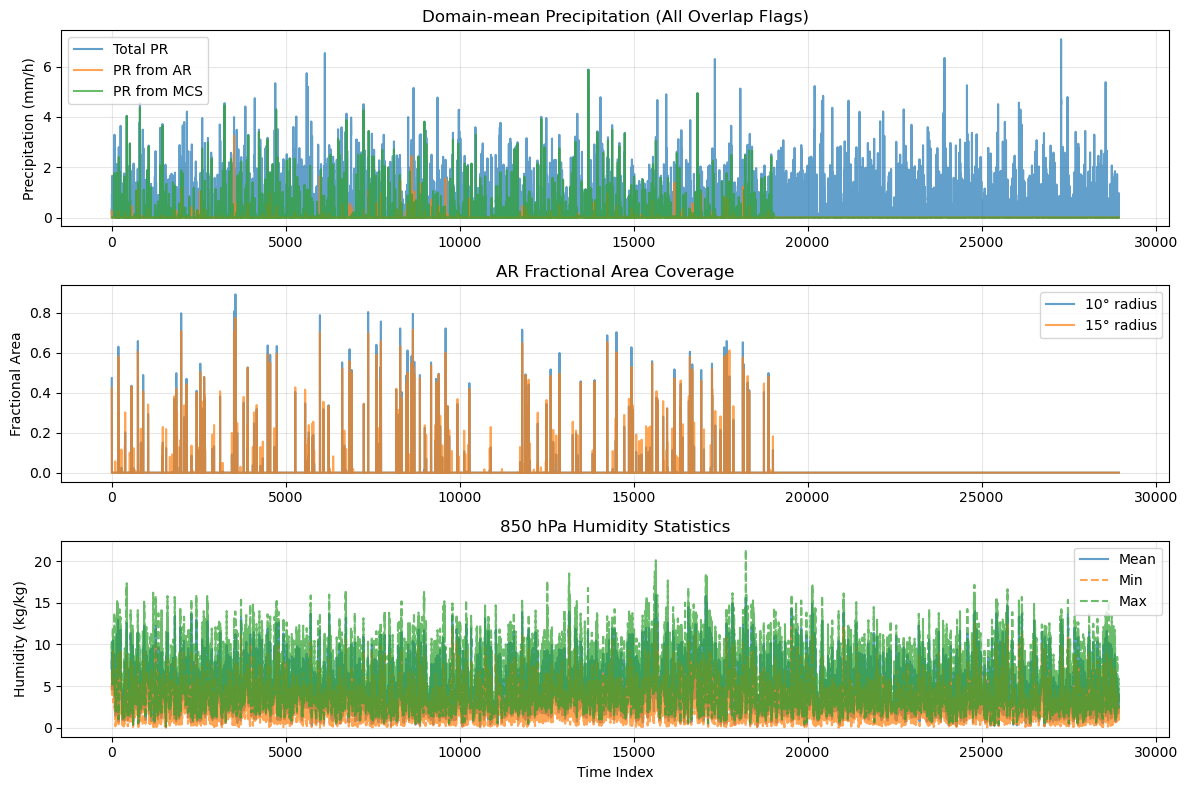

In [52]:
# Plot time series of some variables
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

# Plot 1: Precipitation statistics
axes[0].plot(stats.pr_mean, label='Total PR', alpha=0.7)
if 'pr_ar_mean' in stats:
    axes[0].plot(stats.pr_ar_mean, label='PR from AR', alpha=0.7)
if 'pr_mcs_mean' in stats:
    axes[0].plot(stats.pr_mcs_mean, label='PR from MCS', alpha=0.7)
axes[0].set_ylabel('Precipitation (mm/h)')
axes[0].set_title('Domain-mean Precipitation (All Overlap Flags)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: AR fractional area (if available)
if 'ar_etc_overlap_mask_frac_r10' in stats:
    axes[1].plot(stats.ar_etc_overlap_mask_frac_r10, label='10° radius', alpha=0.7)
    if 'ar_etc_overlap_mask_frac_r15' in stats:
        axes[1].plot(stats.ar_etc_overlap_mask_frac_r15, label='15° radius', alpha=0.7)
    axes[1].set_ylabel('Fractional Area')
    axes[1].set_title('AR Fractional Area Coverage')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

# Plot 3: Humidity mean/min/max
if 'hus_850hPa_mean' in stats:
    axes[2].plot(stats.hus_850hPa_mean, label='Mean', alpha=0.7)
    axes[2].plot(stats.hus_850hPa_min, label='Min', alpha=0.7, linestyle='--')
    axes[2].plot(stats.hus_850hPa_max, label='Max', alpha=0.7, linestyle='--')
    axes[2].set_ylabel('Humidity (kg/kg)')
    axes[2].set_title('850 hPa Humidity Statistics')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

axes[2].set_xlabel('Time Index')
plt.tight_layout()
plt.show()

In [54]:
# Save to NetCDF file (all overlap flags included)
output_file = f'{out_dir}/etc_spatial_stats_{source}.nc'
stats.to_netcdf(output_file)
print(f"Saved statistics to: {output_file}")
print(f"File size: {os.path.getsize(output_file) / 1e6:.2f} MB")
print(f"\nTo filter during analysis, use:")
print(f"  stats_ar_only = stats.where(stats.overlap_flag == 2, drop=True)")
print(f"  stats_3way = stats.where(stats.overlap_flag == 3, drop=True)")

Saved statistics to: /pscratch/sd/w/wcmca1/hackathon/etc_data/stats//etc_spatial_stats_era5.nc
File size: 13.39 MB

To filter during analysis, use:
  stats_ar_only = stats.where(stats.overlap_flag == 2, drop=True)
  stats_3way = stats.where(stats.overlap_flag == 3, drop=True)
